In [ ]:
import xarray as xr 
import cartopy.crs as ccrs 
import numpy as np
from tqdm.notebook import tqdm
import seaborn as sns
import seaborn.objects as so
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn.objects as so
plt.style.use('robin')


In [2]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    """
    Compute the Haversine distance between two points or arrays of points using NumPy.

    Parameters:
        lon1, lat1: float or np.ndarray
            Longitude and latitude of the first point(s) in degrees.
        lon2, lat2: float or np.ndarray
            Longitude and latitude of the second point(s) in degrees.
        radius: float
            Radius of the Earth in kilometers (default is 6371 km).

    Returns:
        np.ndarray or float
            Distance in kilometers.
    """
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c


In [3]:
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
ds_attrs = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/rosendal/4conv_layer_attributions.nc').sortby('attribution_time')[['sensitivity','attributions']]
ds_attrs = ds_attrs.shift(timestep=-1).assign_coords(timestep=np.arange(-3,2)).isel(timestep=range(4))

df_features = df_features.loc[ds_attrs.attribution_time]
df_features.groupby(['rain_type']).count()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,daily_rain
rain_type,,,,,,,,,,,,,,,,,
A,4,4,4,4,3,2,2,2,1,0,0,0,0,0,0,0,4
A_C,10,10,9,8,8,7,5,4,2,1,0,0,0,0,0,0,10
A_C_F,67,67,67,67,66,63,56,49,42,29,17,3,1,1,0,0,67
A_F,9,9,9,9,9,8,6,4,2,1,0,0,0,0,0,0,9
C,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2


In [4]:
ds_preds = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/rosendal/4conv_layer_attributions.nc')[['targets','preds']]
ds_preds

<xarray.Dataset> Size: 360kB
Dimensions:   (time: 4096, timestep: 5)
Coordinates:
  * timestep  (timestep) int64 40B 0 1 2 3 4
    mask_id   int64 8B ...
  * time      (time) datetime64[ns] 33kB 1995-06-13 1995-06-14 ... 2006-08-29
Data variables:
    targets   (time, timestep) float64 164kB ...
    preds     (time, timestep) float64 164kB ...

In [5]:
def get_cyclones_distance_from_time(time):
    features = df_features.loc[time].iloc[:-2].dropna()
    
    cyclones_list = features.loc[features.str.startswith('C_')].str.split('_',expand=True).iloc[:,1].values.astype(float)
    if len(cyclones_list)==0:
        return
    cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()
    cycs['day'] = cycs.date.dt.round('D')

    cycs_extract= cycs.loc[cycs.track_id.isin(cyclones_list)]
    cycs_extract = cycs_extract.loc[cycs_extract.date.round('D')<=pd.to_datetime(time)]
    if len(cycs_extract)==0:
        print('Cyclone filtered out, maybe error')
        return
    grid = xr.zeros_like(ds_attrs.attributions.isel(attribution_time=0, var_name=0, timestep=0))#.expand_dims(time=cycs_extract.day.unique())

    lon_center = cycs_extract.set_index('track_id').lon.to_xarray().rename(track_id = 'cyclone_track_id')
    lat_center = cycs_extract.set_index('track_id').lat.to_xarray().rename(track_id = 'cyclone_track_id')
    date = cycs_extract.set_index('track_id').day.to_xarray().rename(track_id = 'cyclone_track_id')
    track_id = cycs_extract.set_index('track_id').to_xarray().rename(track_id = 'cyclone_track_id').cyclone_track_id

    distances_from_cyclone = haversine_np(lon_center,lat_center,grid+grid.longitude, grid+grid.latitude)
    distances_from_cyclone = distances_from_cyclone.where(distances_from_cyclone == distances_from_cyclone.groupby(date).min())
    distances_from_cyclone = distances_from_cyclone.assign_coords(day=np.arange(-distances_from_cyclone.day.size+1,1)).drop_vars('timestep').rename(day='timestep')
    return distances_from_cyclone.min('cyclone_track_id')


def get_frovo_distance_from_time(time):
    features = df_features.loc[time].iloc[:-2].dropna()
    year, month, day = time.strftime("%Y-%m-%d").split('-')
    fronts_list = features.loc[features.str.startswith('F_')].str.split('_',expand=True).iloc[:,1].values.astype(float)
    if len(fronts_list)==0:
        return

    grid = xr.zeros_like(ds_attrs.isel(timestep=0, var_name=0))#.expand_dims(time=cycs_extract.day.unique())


    file1 = f'/Data/gfi/spengler/jlu044/era5_4D_frovo/frovo_4D_v1_1_mountain_NH/frovo_4D_data_{year}-{month}.nc'
    if int(month)==1:
        year2 = str(int(year)-1)
        month2 = '12'
    else:
        year2=year
        month2 = f"{int(month)-1:02d}"
    file2 = f'/Data/gfi/spengler/jlu044/era5_4D_frovo/frovo_4D_v1_1_mountain_NH/frovo_4D_data_{year2}-{month2}.nc'
    ds1 = xr.open_dataset(file1).frovo_id_mapped
    ds2 = xr.open_dataset(file2).frovo_id_mapped
    frovo = xr.concat([ds2, ds1], dim='time')
    # frovo = xr.open_mfdataset([file1, file2]).load()
    frovo = frovo.rename(dict(lat = 'latitude',lon = 'longitude')).sel(pressure=850).interp_like(grid, method = 'nearest')


    frovo = frovo.where(frovo.isin(fronts_list)).sel(time=slice(None,time))
    frovo = frovo.where(frovo.max(['longitude','latitude']).notnull(), drop=True)
    # # frovo = frovo.resample(time='D').count()
    frovo = frovo.where(frovo>0)#.isel(time=slice(-4,None))
    frovo = frovo.rename(time='timestep').assign_coords(timestep=np.arange(-frovo.time.size+1,1))

    frovo_lat = (frovo-frovo+frovo.latitude).dropna('longitude', how='all').dropna('latitude', how='all').rename(latitude='frovo_latitude',longitude='frovo_longitude')
    frovo_lon = (frovo-frovo+frovo.longitude ).dropna('longitude', how='all').dropna('latitude', how='all').rename(longitude='frovo_longitude',latitude='frovo_latitude')
    lon = xr.zeros_like(frovo)+frovo.longitude
    lat = xr.zeros_like(frovo)+frovo.latitude
    distance_from_frovo = haversine_np(frovo_lon,frovo_lat, lon, lat).min(['frovo_latitude','frovo_longitude'])
    return distance_from_frovo

# cyclones_tracks = (distances.where(distances<distance_from_cyclone)-distances+track_id).max('cyclone_index')

In [7]:
all_ds_features = []
for time in tqdm(df_features.index.round('D')[:]):
    print(time)
    features = dict()
    try:
        distance_from_cyclone = get_cyclones_distance_from_time(time)
        if distance_from_cyclone is not None:
            features['cyclones']= distance_from_cyclone
    except:
        print(f"{time} failed on cyclones")
    try:
        distance_from_frovo = get_frovo_distance_from_time(time)
        if distance_from_frovo is not None:
            features['frovo']= distance_from_frovo
    except:
        print(f"{time} failed on fronts")
    if features != dict():
        ds_features = xr.Dataset(features).to_array('feature').assign_coords(attribution_time=time)
        all_ds_features.append(ds_features)
    
ds_features_attrs = xr.concat(all_ds_features, dim='attribution_time', coords='minimal')


  0%|          | 0/92 [00:00<?, ?it/s]

1995-09-24 00:00:00
1995-10-12 00:00:00
1995-10-19 00:00:00
1995-10-26 00:00:00
1995-11-24 00:00:00
1996-09-30 00:00:00
1996-10-04 00:00:00
1996-10-07 00:00:00
1997-02-07 00:00:00
1997-02-20 00:00:00
1997-02-22 00:00:00
1997-02-23 00:00:00
1997-03-01 00:00:00
1997-03-01 00:00:00 failed on cyclones
1997-03-01 00:00:00 failed on fronts
1997-03-02 00:00:00
1997-09-08 00:00:00
1997-09-17 00:00:00
1998-02-10 00:00:00
1998-02-10 00:00:00 failed on fronts
1998-02-11 00:00:00
1998-02-21 00:00:00
1998-02-23 00:00:00
1998-02-27 00:00:00
1998-02-27 00:00:00 failed on cyclones
1998-10-15 00:00:00
1998-10-23 00:00:00
1998-12-15 00:00:00
1998-12-17 00:00:00
1998-12-18 00:00:00
1998-12-25 00:00:00
1999-01-16 00:00:00
1999-02-04 00:00:00
1999-02-04 00:00:00 failed on cyclones
1999-02-15 00:00:00
1999-02-19 00:00:00
1999-04-09 00:00:00
1999-10-11 00:00:00
1999-10-28 00:00:00
1999-11-01 00:00:00
1999-11-01 00:00:00 failed on fronts
1999-11-25 00:00:00
1999-11-25 00:00:00 failed on cyclones
1999-11-25 00

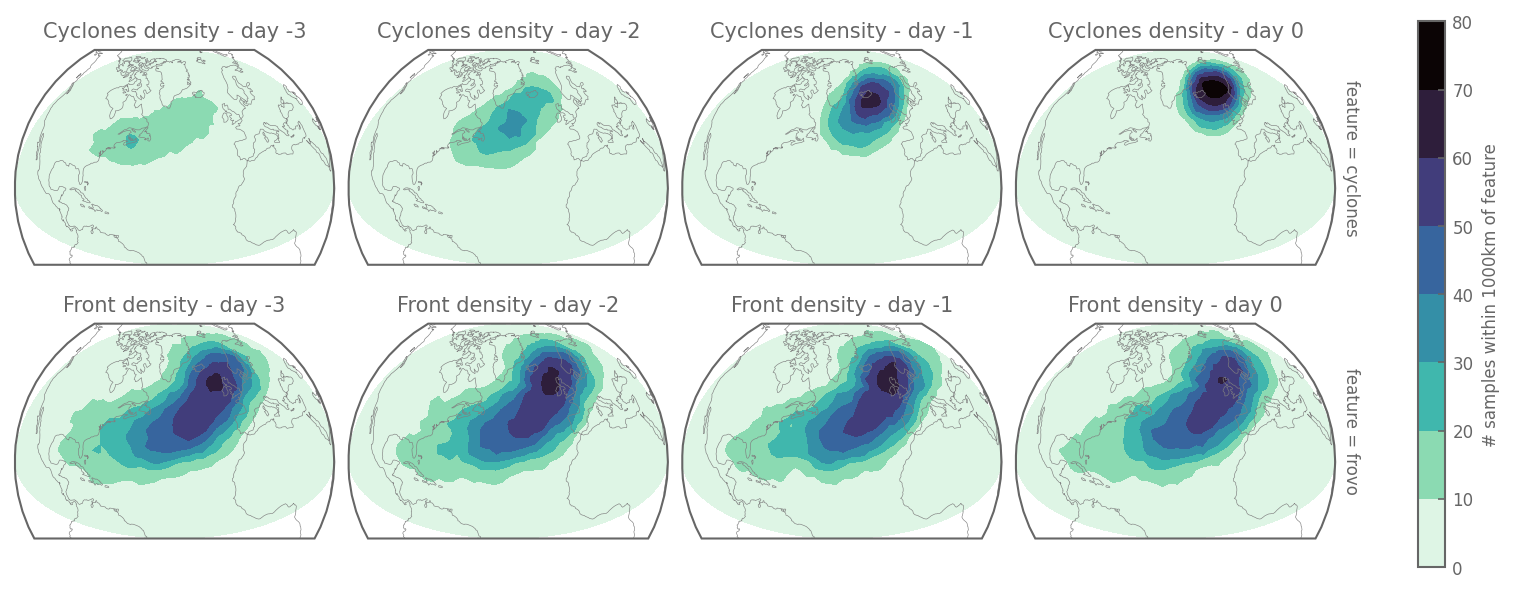

In [33]:
plot = ds_features_attrs.where(ds_features_attrs<1000).count('attribution_time').sel(timestep=range(-3,1)).plot.contourf(levels=np.arange(0,81,10),col='timestep',row='feature', cmap='mako_r', subplot_kws = dict(projection=ccrs.Orthographic(-40, 30)), transform =ccrs.PlateCarree(), size=2, aspect=1.3)
plot.cbar.ax.set_ylabel('# samples within 1000km of feature')

for k, ax in enumerate(plot.axs.flatten()):
    ax.coastlines(linewidth=.3, color='.5')
    if k<4:
        ax.set_title(f'Cyclones density - day {-3+k}')
    if k>=4:
        
        ax.set_title(f'Front density - day {-3+k-4}')

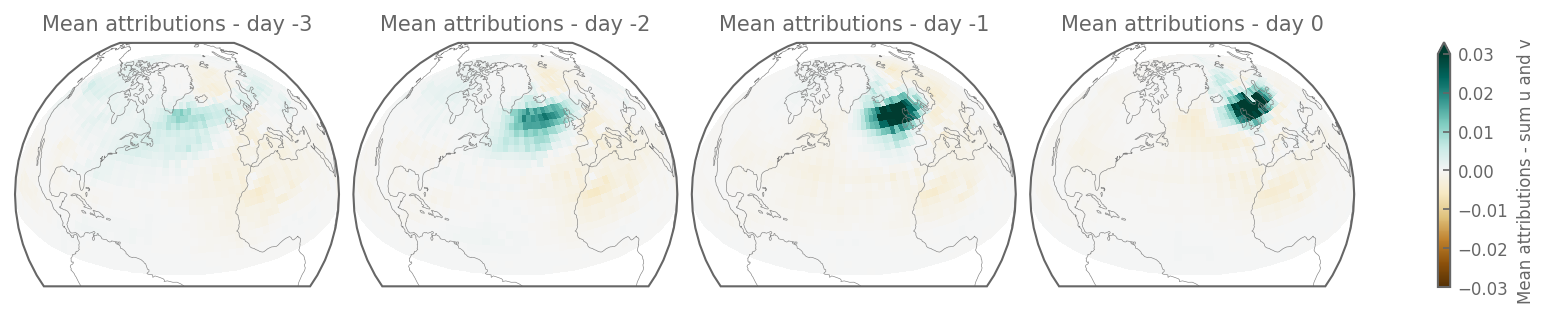

In [44]:
plot = ds_attrs.attributions.mean('attribution_time').sum('var_name').sel(timestep=range(-3,1)).plot(col='timestep', cmap='BrBG', subplot_kws = dict(projection=ccrs.Orthographic(-40, 30)), transform =ccrs.PlateCarree(), size=2, aspect=1.3, vmax=0.03)
plot.cbar.ax.set_ylabel('Mean attributions - sum u and v')

for k, ax in enumerate(plot.axs.flatten()):
    ax.coastlines(linewidth=.3, color='.5')
    if k<4:
        ax.set_title(f'Mean attributions - day {-3+k}')
    if k>=4:
        ax.set_title(f'Front density - day {-3+k-4}')

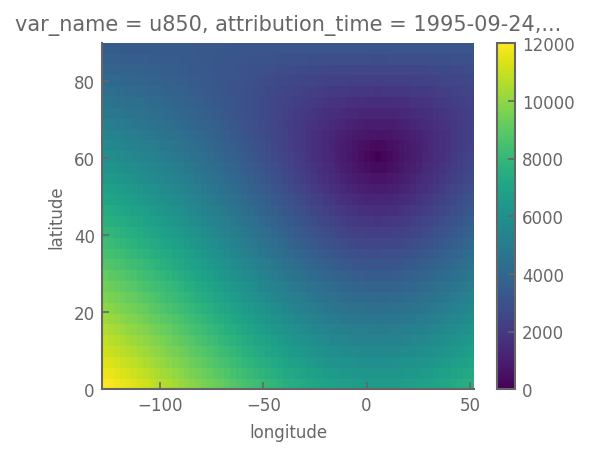

In [153]:
ds_features_attrs = xr.concat(all_ds_features, dim='attribution_time', coords='minimal')
ds_attrs['features_distance'] = ds_features_attrs
# ds_features_attrs.sel(timestep=ds_attrs.attributions.timestep).mean('attribution_time').plot(col='timestep',row='feature')

grid = ds_attrs.attributions.isel(attribution_time=0, timestep=0, var_name=0)

lons = grid-grid+grid.longitude
lats = grid-grid+grid.latitude

ds_regions= xr.open_dataarray('/Data/gfi/share/ModData/CMIP_EU_Precip_Precursors/aux/ERA5_rainfall_regions.nc').rename(lon='longitude',lat='latitude').interp_like(grid)
ds_WN = ds_regions.where(ds_regions==14, drop=True)
dist_to_WN = haversine_np(ds_WN.longitude.values, ds_WN.latitude.values, lons, lats)
dist_to_WN.plot()

# features_distance_ = ds_attrs.features_distance.reindex(feature=['cyclones' 'frovo','WesternNorway'])

# features_distance_.loc[dict(feature='WesternNorway')]=dist_to_WN
features_distance_with_WN = xr.concat([ds_attrs.features_distance, xr.ones_like(ds_attrs.features_distance.isel(feature=0)).assign_coords(feature='WesternNorway')*dist_to_WN], dim='feature')
ds_attrs = ds_attrs.interp_like(features_distance_with_WN)
ds_attrs['features_distance'] = features_distance_with_WN

In [154]:
ds_attrs

<xarray.Dataset> Size: 42MB
Dimensions:            (var_name: 2, feature: 3, attribution_time: 92,
                        timestep: 4, latitude: 32, longitude: 64)
Coordinates:
  * var_name           (var_name) <U4 32B 'u850' 'v850'
  * feature            (feature) object 24B 'cyclones' 'frovo' 'WesternNorway'
    mask_id            int64 8B 14
    pressure           float64 8B 850.0
  * latitude           (latitude) float64 256B 1.406 4.219 7.031 ... 85.78 88.59
  * longitude          (longitude) float64 512B -126.6 -123.8 ... 47.81 50.62
  * attribution_time   (attribution_time) datetime64[ns] 736B 1995-09-24 ... ...
  * timestep           (timestep) int64 32B -3 -2 -1 0
Data variables:
    sensitivity        (attribution_time, timestep, var_name, latitude, longitude) float64 12MB ...
    attributions       (attribution_time, timestep, var_name, latitude, longitude) float64 12MB ...
    features_distance  (attribution_time, feature, latitude, longitude, timestep) float64 18MB ...

In [157]:
df_

,timestep,feature,var_name,features_distance,attributions
0,-3,WesternNorway,u850,100.0,0.282620
1,-3,WesternNorway,u850,300.0,1.341358
2,-3,WesternNorway,u850,500.0,1.828203
3,-3,WesternNorway,u850,700.0,1.419804
4,-3,WesternNorway,u850,900.0,0.467017
...,...,...,...,...,...
1171,0,frovo,v850,8900.0,-0.013411
1172,0,frovo,v850,9100.0,-0.016790
1173,0,frovo,v850,9300.0,-0.012962
1174,0,frovo,v850,9500.0,-0.007374


/tmp/ipykernel_339517/3674681662.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = df_.groupby(['timestep','feature','var_name',pd.cut(df_.features_distance, np.arange(0,10000,500))]).attributions.sum().reset_index()


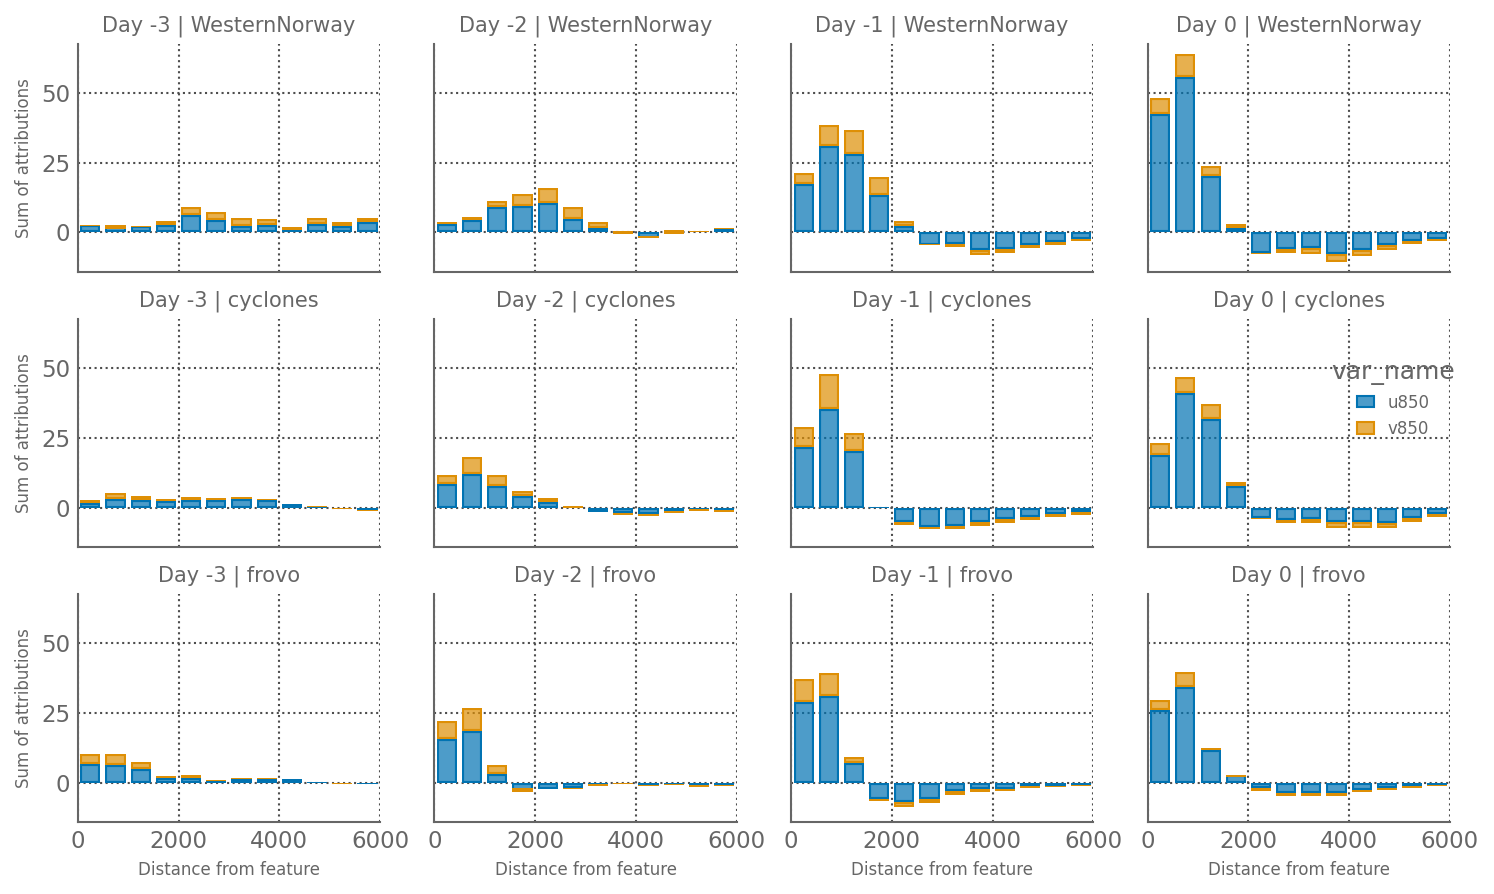

Text(0.5, 0.98, '84 true positive attributions cases')

<Figure size 600x450 with 0 Axes>

In [ ]:
df_ = ds_attrs.where(ds_attrs.features_distance.mean(['longitude','latitude','feature']).count('timestep')).sel(attribution_time='1999-11-28').to_dataframe().reset_index()
df_ = df_.groupby(['timestep','feature','var_name',pd.cut(df_.features_distance, np.arange(0,10000,200))]).attributions.sum().reset_index()
df_['features_distance'] = [k.mid for k in df_.features_distance]
# df_
plot = (so.Plot(df_, x='features_distance', y='attributions', color='var_name')
 .add(so.Bar(),so.Stack())
 .facet(col='timestep', row='feature')
 .layout(size=(10,6))
 .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.3'})
 .limit(x=(0,6000))
 .label(x='Distance from feature', col='Day', y='Sum of attributions',)
 .show()
#  .share(x=True, y=False)
)
# sns.barplot(df_, x='features_distance', y='attributions')
plt.suptitle('84 true positive attributions cases')

In [ ]:
plot.

<xarray.DataArray 'features_distance' (attribution_time: 92)> Size: 736B
array([3, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 0, 4, 4, 4, 2, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 2, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 1, 4, 4, 4, 4, 4, 4, 2, 2,
       4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 2, 4, 4, 4, 0, 0, 4, 4, 4,
       4, 4, 4, 4])
Coordinates:
  * attribution_time  (attribution_time) datetime64[ns] 736B 1995-09-24 ... 2...
    mask_id           int64 8B 14
    pressure          float64 8B 850.0

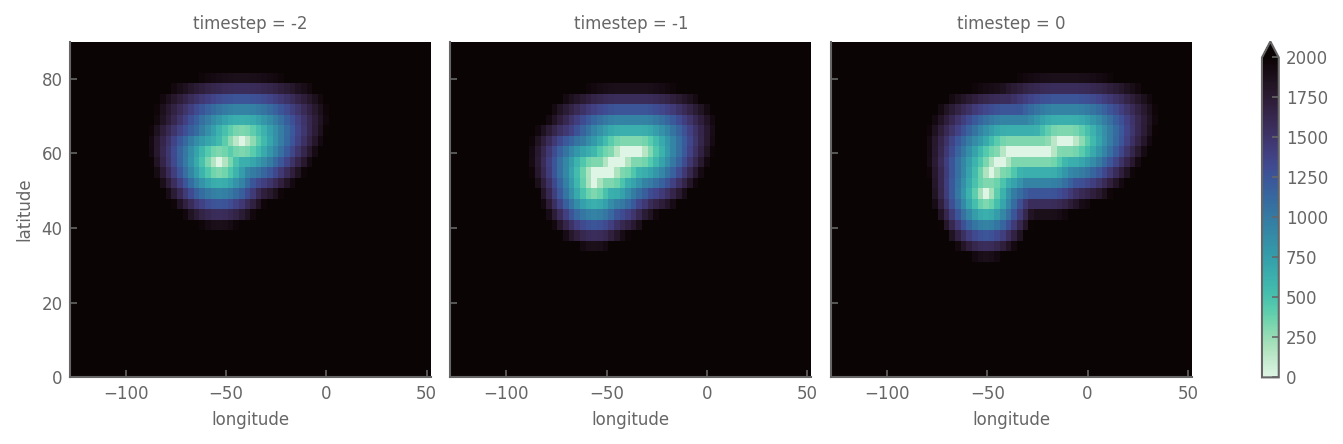

In [199]:
fronts_list = features.loc[features.str.startswith('F_')].str.split('_',expand=True).iloc[:,1].values.astype(float)
grid = xr.zeros_like(ds_attrs.isel(timestep=0, var_name=0))#.expand_dims(time=cycs_extract.day.unique())


file1 = f'/Data/gfi/spengler/jlu044/era5_4D_frovo/frovo_4D_v1_1_mountain_NH/frovo_4D_data_{year}-{month}.nc'
if int(month)==1:
    year2 = str(int(year)-1)
    month2 = '12'
else:
    year2=year
    month2 = f"{int(month)-1:02d}"
file2 = f'/Data/gfi/spengler/jlu044/era5_4D_frovo/frovo_4D_v1_1_mountain_NH/frovo_4D_data_{year2}-{month2}.nc'
ds1 = xr.open_dataset(file1).frovo_id_mapped
ds2 = xr.open_dataset(file2).frovo_id_mapped
frovo = xr.concat([ds2, ds1], dim='time')
# frovo = xr.open_mfdataset([file1, file2]).load()
frovo = frovo.rename(dict(lat = 'latitude',lon = 'longitude')).sel(pressure=850).interp_like(grid, method = 'nearest')


frovo = frovo.where(frovo.isin(fronts_list)).sel(time=slice(None,time))
frovo = frovo.where(frovo.max(['longitude','latitude']).notnull(), drop=True)
# # frovo = frovo.resample(time='D').count()
frovo = frovo.where(frovo>0)#.isel(time=slice(-4,None))
frovo = frovo.rename(time='timestep').assign_coords(timestep=np.arange(-frovo.time.size+1,1))

frovo_lat = (frovo-frovo+frovo.latitude).dropna('longitude', how='all').dropna('latitude', how='all').rename(latitude='frovo_latitude',longitude='frovo_longitude')
frovo_lon = (frovo-frovo+frovo.longitude ).dropna('longitude', how='all').dropna('latitude', how='all').rename(longitude='frovo_longitude',latitude='frovo_latitude')
lon = xr.zeros_like(frovo)+frovo.longitude
lat = xr.zeros_like(frovo)+frovo.latitude
distance_from_frovo = haversine_np(frovo_lon,frovo_lat, lon, lat).min(['frovo_latitude','frovo_longitude'])

distance_from_frovo.plot(col='timestep', cmap='mako_r', vmax=2000)

In [201]:
mta_list = features.loc[features.str.startswith('A_')].str.split('_',expand=True).iloc[:,1].values.astype(float)
mta_list



array([11., 12., 13., 14., 16., 17., 17.])

<xarray.DataArray (timestep: 13, latitude: 32, longitude: 64)> Size: 213kB
array([[[ 6915.27863249,  6895.81112225,  6884.09661595, ...,
         12170.36298897, 12184.97452356, 12193.76128086],
        [ 6603.4378552 ,  6583.47582434,  6571.46139785, ...,
         11858.11010232, 11872.45448302, 11881.07963717],
        [ 6291.65058587,  6271.16466475,  6258.83226865, ...,
         11545.8432502 , 11559.92815089, 11568.39640776],
        ...,
        [ 1563.67865594,  1565.06945792,  1569.23127677, ...,
          3120.90678633,  3124.48904156,  3126.64003882],
        [ 1876.41438713,  1877.11418398,  1879.21037273, ...,
          2810.34855568,  2812.72129913,  2814.14633642],
        [ 2189.15011831,  2189.35130316,  2189.95426668, ...,
          2500.29386644,  2501.17770919,  2501.70872556]],

       [[ 7019.20182415,  6977.10475033,  6942.41510384, ...,
         12425.93069976, 12455.84237108, 12479.22153497],
        [ 6709.92006224,  6666.80263187,  6631.25560196, ...,
         12114.92487687, 12144.22462536, 12167.11947348],
        [ 6400.83592096,  6356.64226449,  6320.18926799, ...,
         11803.86180992, 11832.56930337, 11854.99585531],
...
        [ 3145.61266736,  3137.65239114,  3131.94133648, ...,
          4054.08800401,  4092.12874664,  4130.33342206],
        [ 3450.16620885,  3445.7704345 ,  3442.61990477, ...,
          4106.65911197,  4129.30626767,  4152.12588852],
        [ 3755.9413369 ,  3754.58233438,  3753.60900655, ...,
          4051.0319136 ,  4054.04626884,  4056.72170193]],

       [[ 5726.04452047,  5683.91655881,  5653.61402307, ...,
          7798.21598826,  7959.20048132,  8123.58976655],
        [ 5417.16167357,  5373.37937588,  5341.86559225, ...,
          7529.79548536,  7692.91151722,  7859.2568161 ],
        [ 5108.62382542,  5063.0425111 ,  5030.20825379, ...,
          7263.0614056 ,  7428.25411767,  7596.4843398 ],
        ...,
        [ 3457.98401937,  3450.18115338,  3444.5844381 , ...,
          3527.49120232,  3562.74757963,  3598.7340543 ],
        [ 3762.78976056,  3758.44257559,  3755.32721731, ...,
          3666.71307126,  3687.22296002,  3708.24033026],
        [ 3978.2404744 ,  3971.32540255,  3964.25747596, ...,
          3824.24994827,  3830.85418972,  3837.64526721]]])
Coordinates:
    pressure   float64 8B 850.0
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude  (longitude) float64 512B -126.6 -123.8 -120.9 ... 47.81 50.62
  * timestep   (timestep) int64 104B -12 -11 -10 -9 -8 -7 -6 -5 -4 -3 -2 -1 0